In [133]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Data Gathering and cleaning

In [134]:
df = pd.read_csv("../data/raw/movies_metadata.csv")

In [135]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [136]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='str')

In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  str    
 1   belongs_to_collection  4494 non-null   str    
 2   budget                 45466 non-null  str    
 3   genres                 45466 non-null  str    
 4   homepage               7782 non-null   str    
 5   id                     45466 non-null  str    
 6   imdb_id                45449 non-null  str    
 7   original_language      45455 non-null  str    
 8   original_title         45466 non-null  str    
 9   overview               44512 non-null  str    
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  str    
 12  production_companies   45463 non-null  str    
 13  production_countries   45463 non-null  str    
 14  release_date           45379 non-null  str    
 15  revenue      

In [138]:
df.shape

(45466, 24)

In [139]:
#each column has how many null value
df.isnull().sum()


adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64

In [140]:
#How many duplicate row
df.duplicated().sum()

np.int64(13)

In [141]:
# remove all duplicate row and reset the index number after remover duplicate row
df = df.drop_duplicates().reset_index(drop = True)

In [142]:
df = df[['title', 'overview', 'genres', 'tagline','vote_average', 'popularity']]

In [143]:
df.duplicated().sum()

np.int64(0)

In [144]:
df


,title,overview,genres,tagline,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",NaN,7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",Roll the dice and unleash the excitement!,6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",Friends are the people who let you be yourself...,6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]",Just When His World Is Back To Normal... He's ...,5.7,8.387519
...,...,...,...,...,...,...
45448,Subdue,Rising and falling between a man and woman.,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",Rising and falling between a man and woman,4.0,0.072051
45449,Century of Birthing,An artist struggles to finish his work while a...,"[{'id': 18, 'name': 'Drama'}]",NaN,9.0,0.178241
45450,Betrayal,"When one of her hits goes wrong, a professiona...","[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",A deadly game of wits.,3.8,0.903007
45451,Satan Triumphant,"In a small town live two brothers, one a minis...",[],NaN,0.0,0.003503


In [145]:
df.isnull().sum()

title               6
overview          954
genres              0
tagline         25045
vote_average        6
popularity          5
dtype: int64

In [146]:
#drop all null value row from title column
df = df.dropna(subset =['title'])

In [147]:
df

,title,overview,genres,tagline,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",NaN,7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",Roll the dice and unleash the excitement!,6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",Friends are the people who let you be yourself...,6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]",Just When His World Is Back To Normal... He's ...,5.7,8.387519
...,...,...,...,...,...,...
45448,Subdue,Rising and falling between a man and woman.,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",Rising and falling between a man and woman,4.0,0.072051
45449,Century of Birthing,An artist struggles to finish his work while a...,"[{'id': 18, 'name': 'Drama'}]",NaN,9.0,0.178241
45450,Betrayal,"When one of her hits goes wrong, a professiona...","[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",A deadly game of wits.,3.8,0.903007
45451,Satan Triumphant,"In a small town live two brothers, one a minis...",[],NaN,0.0,0.003503


In [148]:
#if overview column has numeric value then we use mean or median or mode for fill the null value but if text then we use () dash
df['overview'] = df['overview'].fillna('')

In [149]:
# give from first row get first genres values
df.iloc[0]['genres']

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [150]:
 # Import ast module to convert a string representation of a Python object into an actual Python object.
import ast
new_genres = []

for genre in df['genres']:
    # Convert the string into a Python list of dictionaries.
    # "[{'id':16,'name':'Animation'},{'id':35,'name':'Comedy'}]"
    # After:
    # [
    #   {'id':16,'name':'Animation'},
    #   {'id':35,'name':'Comedy'}
    # ]
    genre = ast.literal_eval(genre)

    genre_names  = []
    for item in genre:
        genre_names.append(item['name'])

    
    new_genres.append(" ".join(genre_names))
    

    #we also use this short form 
    # df['genres'] = df['genres'].apply(lambda x: " ".join([i['name'] for i in ast.literal_eval(x)]))
df['genres'] = new_genres

In [151]:
df.head()


,title,overview,genres,tagline,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,NaN,7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,Roll the dice and unleash the excitement!,6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,Friends are the people who let you be yourself...,6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,Just When His World Is Back To Normal... He's ...,5.7,8.387519


In [152]:

df['tagline'] = df['tagline'].fillna('')

In [153]:

df.isnull().sum()

title           0
overview        0
genres          0
tagline         0
vote_average    0
popularity      0
dtype: int64

In [154]:
#create a new column tags for merger all text for convert this into vector
df['tags'] = df['overview']  + " " + df['genres'] + " " + df['tagline']

In [155]:
df['tags'][1]

"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures. Adventure Fantasy Family Roll the dice and unleash the excitement!"

NLP Text preprocessing 

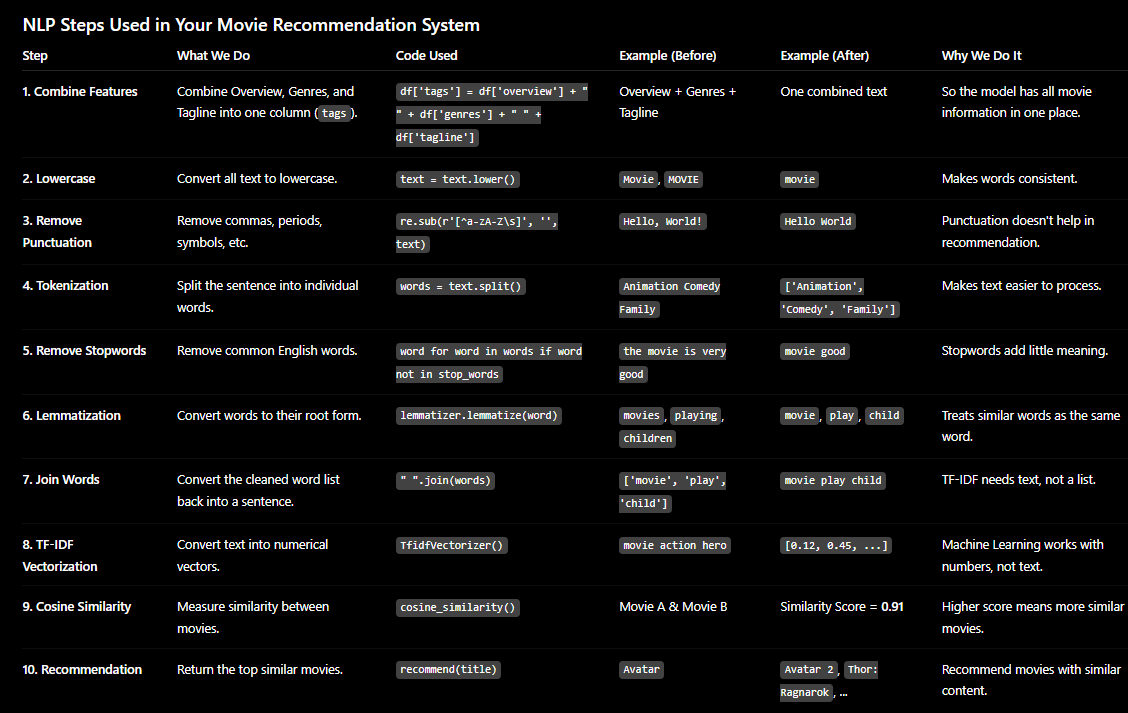

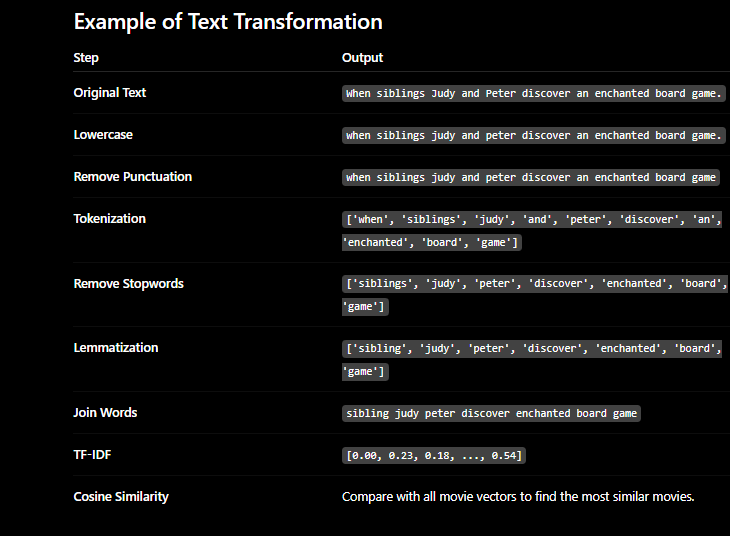

In [156]:
#NLTK (Natural Language Toolkit) is a Python library for Natural Language Processing.
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# re means regular expressition
import re


In [157]:
#download pakages 
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sadman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Sadman\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [158]:
#It loads all the English stopwords from the NLTK library.
stop_words = set(stopwords.words('english'))
print(stopwords.words('english'))

#creates a WordNetLemmatizer object.
lemmatizer = WordNetLemmatizer()

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [159]:
def process_text(text):
    #convert all to lowercase
    text = str(text).lower()

    #removed all punctuation
    text = re.sub(r'[a^-zA\s]', '', text)

    # Tokenization
    words = text.split()

    #removed stopwords

    new_words = []

    for word in words:
        if word not in stop_words:
            new_words.append(word)

    words = new_words

    # shortcut   least comprehention 
    #words = [lemmatizer.lemmatize(word) for word in words]

    #Lemmatization -> convert all words in their root form

    lem_words = []
    for word in words:
        root_word = lemmatizer.lemmatize(word)
        lem_words.append(root_word)
    
    words = lem_words

    return " ".join(words)
  # shortcut least comprehention in python
    #filtered_words = [word for word in words if word not in stop_words]

In [160]:
df['tags'] = df['tags'].apply(process_text)
     

In [161]:
df = df.reset_index(drop=True)

In [ ]:
# WE USE PANDAS SERIES DATFRAME FOR CREATE INDICES OR ALSO USE DICTIONARY
# we need indices for cosine similarity
indices = pd.Series(df.index,index = df['title']).drop_duplicates()

In [166]:
indices

title
Toy Story                          0
Jumanji                            1
Grumpier Old Men                   2
Waiting to Exhale                  3
Father of the Bride Part II        4
                               ...  
Subdue                         45442
Century of Birthing            45443
Betrayal                       45444
Satan Triumphant               45445
Queerama                       45446
Length: 45447, dtype: int64